In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import re
from io import StringIO


def extract_nationality_from_flag(cell):
    """
    Extract nationality from a flag image embedded in a Wikipedia table cell.
    Falls back to plain text if no image is found.

    Parameters
    ----------
    cell : bs4.element.Tag or None
        A BeautifulSoup table cell element.

    Returns
    -------
    str or None
        Country name extracted from the flag's alt/title attribute, or raw
        cell text if no image is present. Returns None for empty cells.
    """
    if cell is None:
        return None

    img = cell.find('img')
    if img:
        alt_text = img.get('alt', '')
        if alt_text:
            return alt_text.strip()
        title_text = img.get('title', '')
        if title_text:
            return title_text.strip()

    text = cell.get_text(strip=True)
    return text if text else None


def _plot_scatter(stats_df, entity_col, title):
    """
    Shared helper that plots a 2-D scatter of unique players vs wins
    for either nations or clubs.

    Parameters
    ----------
    stats_df : pd.DataFrame
        DataFrame indexed by entity (nation / club) with columns
        'Unique_Players' and 'Wins'.
    entity_col : str
        Label used on the chart (e.g. 'Nation' or 'Club').
    title : str
        Chart title.
    """
    distinct_colors = [
        '#e6194B', '#3cb44b', '#ffe119', '#4363d8', '#f58231',
        '#911eb4', '#42d4f4', '#f032e6', '#bfef45', '#fabed4',
        '#469990', '#dcbeff', '#9A6324', '#fffac8', '#800000',
        '#aaffc3', '#808000', '#ffd8b1', '#000075', '#a9a9a9'
    ]

    sorted_df = stats_df.sort_values(
        by=['Wins', 'Unique_Players'], ascending=[False, False]
    )

    plt.figure(figsize=(12, 8))
    for i, (entity, row) in enumerate(sorted_df.iterrows()):
        color = distinct_colors[i % len(distinct_colors)]
        plt.scatter(
            row['Unique_Players'], row['Wins'],
            s=180, alpha=0.8, c=color,
            edgecolors='black', linewidth=2,
            label=entity
        )

    plt.title(title, fontsize=16, fontweight='bold', pad=20)
    plt.xlabel(f'Number of Unique Players in Top 3', fontsize=13)
    plt.ylabel('Number of Wins', fontsize=13)
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.legend(
        bbox_to_anchor=(1.05, 1), loc='upper left',
        fontsize=11, frameon=True, shadow=True,
        ncol=1 if len(stats_df) <= 20 else 2
    )
    plt.tight_layout()
    plt.show()


def ballon_dor_scraper(url, start, end, PerfQuery, viz="None"):
    """
    Scrape, clean, and analyse Ballon d'Or data from Wikipedia.

    Parameters
    ----------
    url : str
        URL of the Ballon d'Or Wikipedia page.
    start : int
        Start year of the query range (inclusive).
    end : int
        End year of the query range (inclusive).
    PerfQuery : str
        Player name to query (partial match, case-insensitive).
    viz : str, optional
        Visualisation mode. One of:
          - 'None'   : no chart (default)
          - 'Player' : bar chart of top-10 winners
          - 'Nation' : scatter plot of unique players vs wins by nationality
          - 'Club'   : scatter plot of unique players vs wins by club

    Returns
    -------
    pd.DataFrame
        Filtered DataFrame with columns:
        Year, Player, Nationality, Club, Points, Winner.
    """

    # ============================================
    # STEP 1: Fetch the webpage
    # ============================================
    headers = {
        'User-Agent': (
            'Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
            'AppleWebKit/537.36 (KHTML, like Gecko) '
            'Chrome/91.0.4472.124 Safari/537.36'
        )
    }
    response = requests.get(url, headers=headers)

    if response.status_code != 200:
        raise Exception(f"Failed to fetch page. Status code: {response.status_code}")

    soup = BeautifulSoup(response.content, 'html.parser')

    # ============================================
    # STEP 2: Find all relevant tables
    # ============================================
    all_tables = soup.find_all('table', {'class': 'wikitable'})

    # ============================================
    # STEP 3: Extract data from tables
    # ============================================
    all_dataframes = []
    main_ballondor_data = []

    for i, table in enumerate(all_tables):
        try:
            header_row = table.find('tr')
            col_names = []
            if header_row:
                col_names = [
                    th.get_text(strip=True).lower()
                    for th in header_row.find_all(['th', 'td'])
                ]

            is_main_table = (
                any('year' in h for h in col_names) and
                any('player' in h or 'name' in h for h in col_names)
            )

            if is_main_table:
                rows = table.find_all('tr')
                header_cells = rows[0].find_all(['th', 'td'])
                header_texts = [cell.get_text(strip=True).lower() for cell in header_cells]

                year_idx   = next((idx for idx, h in enumerate(header_texts) if 'year'   in h), None)
                rank_idx   = next((idx for idx, h in enumerate(header_texts) if 'rank'   in h), None)
                player_idx = next((idx for idx, h in enumerate(header_texts) if 'player' in h or 'name' in h), None)
                club_idx   = next((idx for idx, h in enumerate(header_texts) if 'club'   in h or 'team' in h), None)
                points_idx = next((idx for idx, h in enumerate(header_texts) if 'point'  in h or 'vote' in h), None)

                current_year = None

                for row in rows[1:]:
                    cells = row.find_all(['td', 'th'])
                    if len(cells) < 3:
                        continue

                    row_data = {}
                    first_cell_text = cells[0].get_text(strip=True)
                    has_year_cell = bool(re.match(r'^\d{4}$', first_cell_text))

                    if has_year_cell:
                        current_year = first_cell_text
                        row_data['Year'] = current_year
                        offset = 0
                    else:
                        row_data['Year'] = current_year
                        offset = 1

                    def _get(idx):
                        """Safe cell getter with offset applied."""
                        if idx is None:
                            return None
                        adjusted = idx - offset
                        return cells[adjusted] if 0 <= adjusted < len(cells) else None

                    rank_cell = _get(rank_idx)
                    if rank_cell is not None:
                        row_data['Rank'] = rank_cell.get_text(strip=True)

                    player_cell = _get(player_idx)
                    if player_cell is not None:
                        row_data['Nationality'] = extract_nationality_from_flag(player_cell)
                        row_data['Player'] = player_cell.get_text(strip=True)

                    club_cell = _get(club_idx)
                    if club_cell is not None:
                        row_data['Club'] = club_cell.get_text(strip=True)

                    points_cell = _get(points_idx)
                    if points_cell is not None:
                        row_data['Points'] = points_cell.get_text(strip=True)

                    if 'Year' in row_data and 'Rank' in row_data and 'Player' in row_data:
                        main_ballondor_data.append(row_data)

                if main_ballondor_data:
                    all_dataframes.append(pd.DataFrame(main_ballondor_data))

            else:
                df_list = pd.read_html(StringIO(str(table)))
                if df_list:
                    all_dataframes.append(df_list[0])

        except Exception as e:
            print(f"  Table {i+1}: Skipped (error: {e})")
            continue

    # ============================================
    # STEP 4: Standardise column names
    # ============================================
    def standardize_columns(df):
        df = df.copy()

        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        else:
            df.columns = [
                col[0] if isinstance(col, tuple) and col[0] else str(col)
                for col in df.columns
            ]

        df.columns = df.columns.astype(str)

        mapping = {}
        for col in df.columns:
            c = col.lower().strip()
            if   'rank'     in c:                       mapping[col] = 'Rank'
            elif 'year'     in c:                       mapping[col] = 'Year'
            elif 'player'   in c or 'name' in c:        mapping[col] = 'Player'
            elif 'national' in c or 'nation' in c:      mapping[col] = 'Nationality'
            elif 'club'     in c or 'team' in c:        mapping[col] = 'Club'
            elif 'point'    in c or 'vote' in c:        mapping[col] = 'Points'

        return df.rename(columns=mapping)

    standardized_dfs = [standardize_columns(df) for df in all_dataframes]

    # ============================================
    # STEP 5: Merge all tables into one DataFrame
    # ============================================
    df_combined = pd.concat(standardized_dfs, ignore_index=True)

    # ============================================
    # STEP 6: Clean the data
    # ============================================

    def clean_text(text):
        """Remove footnote markers such as [note 1], [a], (1) from strings."""
        if pd.isna(text):
            return text
        text = re.sub(r'\[.*?\]', '', str(text))
        text = re.sub(r'\(\d+\)', '', text)
        return text.strip()

    for col in ('Player', 'Club'):
        if col in df_combined.columns:
            df_combined[col] = df_combined[col].apply(clean_text)

    def extract_year(year_val):
        """Extract a 4-digit year (1900–2099) from a string value."""
        if pd.isna(year_val):
            return None
        match = re.search(r'\b(19\d{2}|20\d{2})\b', str(year_val))
        return int(match.group(1)) if match else None

    if 'Year' in df_combined.columns:
        df_combined['Year'] = df_combined['Year'].apply(extract_year)
    else:
        print("Warning: No 'Year' column found!")

    df_combined = df_combined.dropna(subset=['Year', 'Player'])

    if len(df_combined) == 0:
        print("ERROR: No data remaining after dropping missing values.")
        return pd.DataFrame(columns=['Year', 'Player', 'Nationality', 'Club', 'Points', 'Winner'])

    df_combined['Year'] = df_combined['Year'].astype(int)

    # Create Winner column
    if 'Rank' in df_combined.columns:
        rank_str = df_combined['Rank'].astype(str).str.lower().str.strip()
        df_combined['Winner'] = rank_str.isin(['1', '1st', '1.0', 'first'])
        df_combined = df_combined[rank_str.isin(['1st', '2nd', '3rd'])]
    else:
        if 'Points' in df_combined.columns:
            df_combined['Points'] = pd.to_numeric(df_combined['Points'], errors='coerce')
            df_combined = df_combined.sort_values(['Year', 'Points'], ascending=[True, False])
        else:
            df_combined = df_combined.sort_values('Year')
        df_combined['Winner'] = ~df_combined.duplicated(subset=['Year'], keep='first')
        df_combined = df_combined.groupby('Year').head(3)

    df_combined['Winner'] = df_combined['Winner'].astype(bool)
    df_combined = df_combined.reset_index(drop=True)

    # ============================================
    # STEP 7: Filter by year range
    # ============================================
    df_filtered = df_combined[
        (df_combined['Year'] >= start) & (df_combined['Year'] <= end)
    ].reset_index(drop=True)

    required_cols = ['Year', 'Player', 'Nationality', 'Club', 'Points', 'Winner']
    for col in required_cols:
        if col not in df_filtered.columns:
            df_filtered[col] = None
    df_filtered = df_filtered[required_cols]

    # ============================================
    # STEP 8: Player query
    # ============================================
    player_data = df_filtered[
        df_filtered['Player'].str.contains(PerfQuery, case=False, na=False)
    ]
    top3_count = len(player_data)
    wins_count = int(player_data['Winner'].sum())

    print(
        f"Between the years {start} and {end}, {PerfQuery} was in Top 3 "
        f"for the Ballon d'Or Award {top3_count} times. "
        f"Among those, {PerfQuery} won the award {wins_count} times."
    )

    # ============================================
    # STEP 9–11: Visualisations
    # ============================================
    if viz == "Player":
        winners_df = df_filtered[df_filtered['Winner']]
        if winners_df.empty:
            print("No winners found in the filtered data. Cannot create visualisation.")
        else:
            player_wins = winners_df['Player'].value_counts().head(10)
            plt.figure(figsize=(10, 6))
            player_wins.plot(kind='bar', color='steelblue')
            plt.title("Top 10 Players with Most Ballon d'Or Wins", fontsize=14, fontweight='bold')
            plt.xlabel('Player', fontsize=12)
            plt.ylabel('Number of Wins', fontsize=12)
            plt.xticks(rotation=45, ha='right')
            plt.tight_layout()
            plt.show()

    elif viz in ("Nation", "Club"):
        group_col = 'Nationality' if viz == "Nation" else 'Club'
        label     = 'Nation'      if viz == "Nation" else 'Club'

        if df_filtered[group_col].isna().all():
            print(f"Warning: {label} data not available. Skipping visualisation.")
        else:
            unique_players = df_filtered.groupby(group_col)['Player'].nunique()
            wins           = df_filtered[df_filtered['Winner']].groupby(group_col).size()
            stats = pd.DataFrame({'Unique_Players': unique_players, 'Wins': wins}).fillna(0)

            if stats.empty:
                print(f"No {label} data available for visualisation.")
            else:
                _plot_scatter(
                    stats,
                    entity_col=label,
                    title=f"Ballon d'Or: Unique Players vs Wins by {label}"
                )

    return df_filtered


In [2]:
# ── Test Case 1: Basic query, no visualisation ──────────────────────────────
url      = "https://en.wikipedia.org/wiki/Ballon_d%27Or"
start    = 2000
end      = 2023
PerfQuery = "Lionel Messi"

df = ballon_dor_scraper(url, start, end, PerfQuery, viz="None")
print("\nFirst 5 rows:")
df.head()

Between the years 2000 and 2023, Lionel Messi was in Top 3 for the Ballon d'Or Award 14 times. Among those, Lionel Messi won the award 8 times.

First 5 rows:


,Year,Player,Nationality,Club,Points,Winner
0,2000,Luís Figo,Portugal,Real Madrid,197,True
1,2000,Zinedine Zidane,France,Juventus,181,False
2,2000,Andriy Shevchenko,Ukraine,Milan,85,False
3,2001,Michael Owen,England,Liverpool,176,True
4,2001,Raúl,Spain,Real Madrid,140,False


Between the years 2000 and 2023, Lionel Messi was in Top 3 for the Ballon d'Or Award 14 times. Among those, Lionel Messi won the award 8 times.


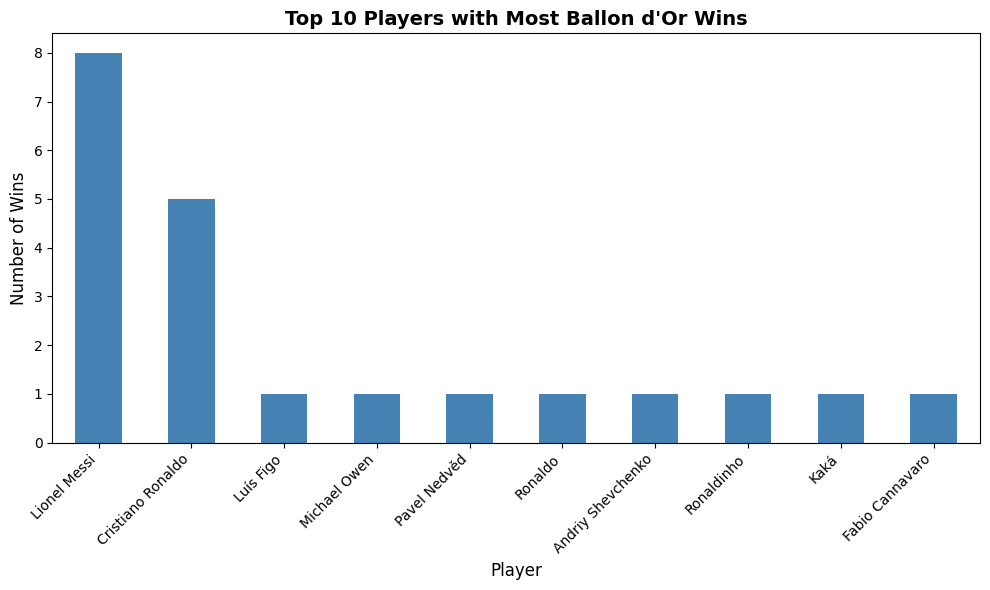

In [3]:
# ── Test Case 2: Player visualisation ───────────────────────────────────────
df = ballon_dor_scraper(url, start, end, PerfQuery, viz="Player")

Between the years 2000 and 2023, Lionel Messi was in Top 3 for the Ballon d'Or Award 14 times. Among those, Lionel Messi won the award 8 times.


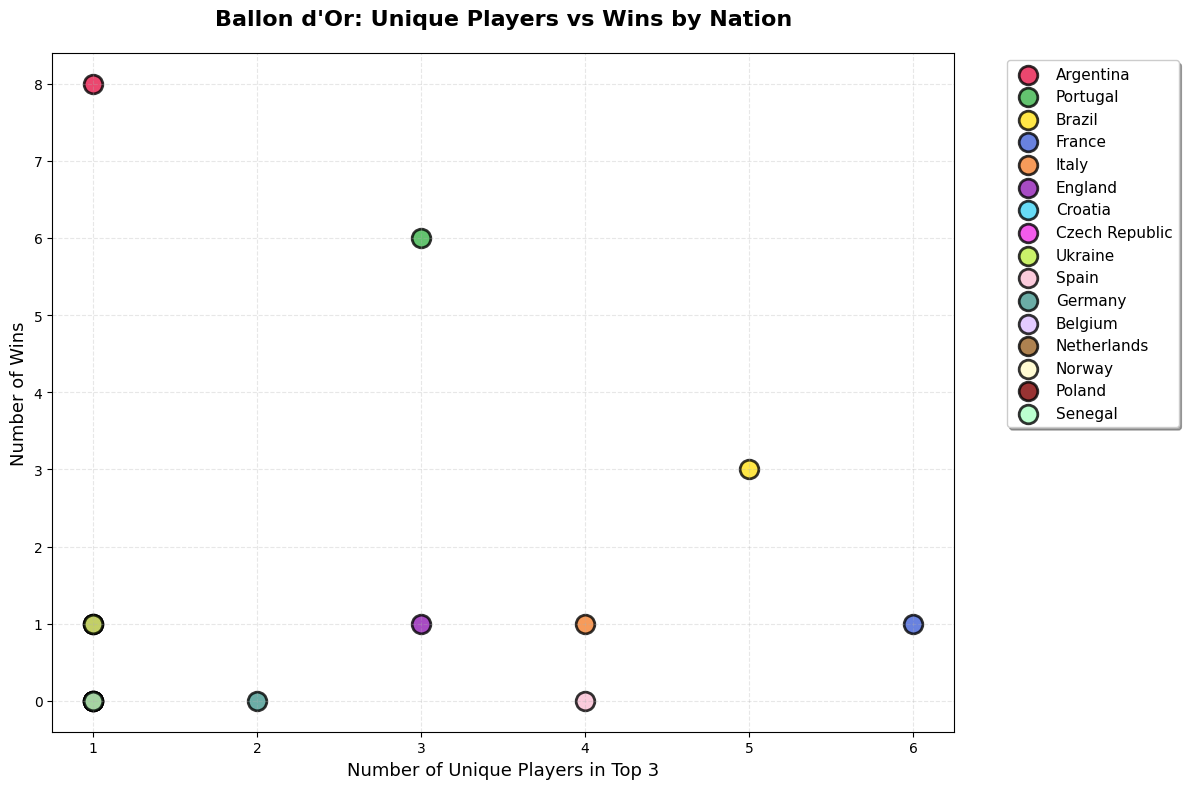

In [4]:
# ── Test Case 3: Nation visualisation ───────────────────────────────────────
df = ballon_dor_scraper(url, start, end, PerfQuery, viz="Nation")

Between the years 2000 and 2023, Lionel Messi was in Top 3 for the Ballon d'Or Award 14 times. Among those, Lionel Messi won the award 8 times.


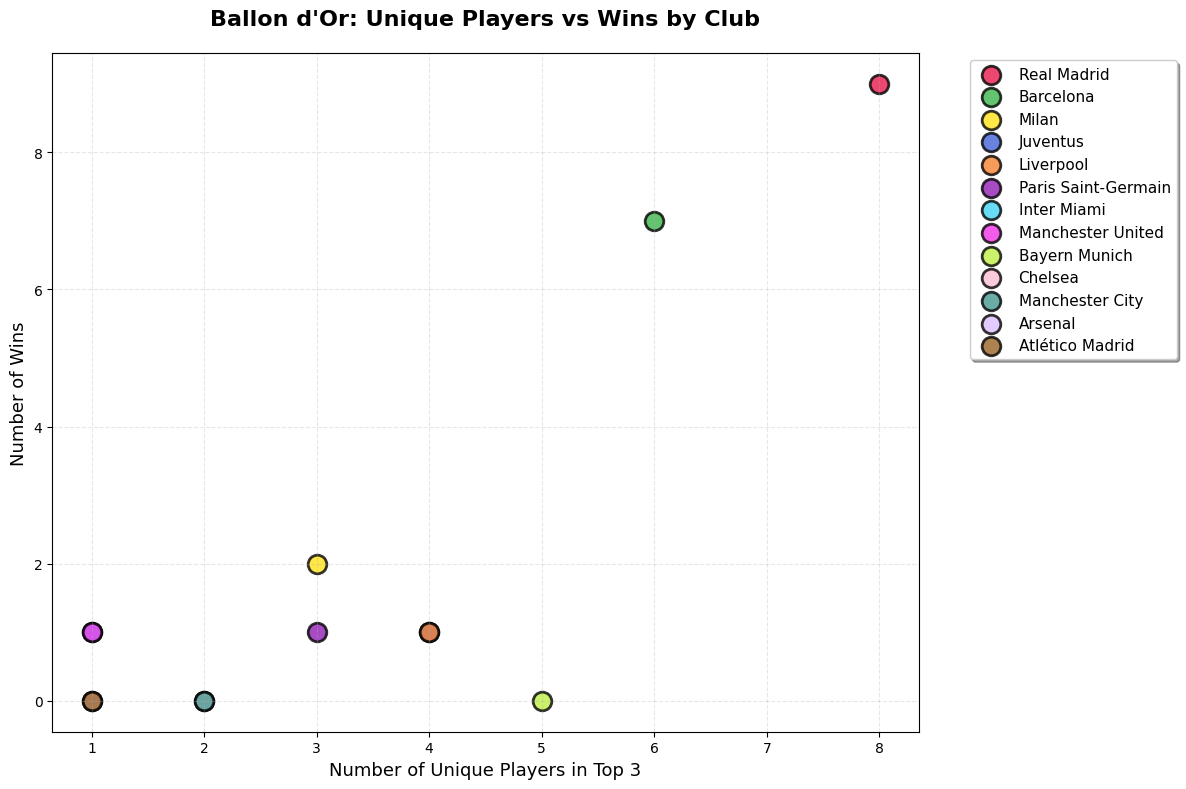

In [5]:
# ── Test Case 4: Club visualisation ─────────────────────────────────────────
df = ballon_dor_scraper(url, start, end, PerfQuery, viz="Club")